In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time-series analysis
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Statistical test
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/exchange_rate.csv")
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [ ]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (7588, 2)

Column Names:
['date', 'Ex_rate']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [ ]:
# Convert the first column into datetime format

date_column = df.columns[0]

df[date_column] = pd.to_datetime(
    df[date_column],
    errors='coerce'
)

# Set date as index
df.set_index(date_column, inplace=True)

# Sort data according to date
df.sort_index(inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7500
1990-01-03,0.7471
1990-01-04,0.7587
1990-01-05,0.7852


In [ ]:
# Get the name of the exchange-rate column
rate_column = df.columns[0]

print("Exchange Rate Column:", rate_column)

# Create a separate time series
ts = df[rate_column].copy()

print(ts.head())

Exchange Rate Column: Ex_rate
date
1990-01-01    0.7855
1990-01-02    0.7500
1990-01-03    0.7471
1990-01-04    0.7587
1990-01-05    0.7852
Name: Ex_rate, dtype: float64


In [ ]:
ts = df[rate_column].copy()

In [ ]:
# Check missing values
print("Missing values:")
print(ts.isnull().sum())

Missing values:
0


In [ ]:
import numpy as np

# Remove NaT values from the index before interpolation
ts = ts[ts.index.notna()]

# Interpolate missing values
ts = ts.interpolate(method='time')

# Forward fill / backward fill any remaining missing values
ts = ts.ffill().bfill()

print("Missing values after preprocessing:", ts.isnull().sum())

Missing values after preprocessing: 0


In [ ]:
# Check duplicate dates
print("Duplicate dates:", ts.index.duplicated().sum())

Duplicate dates: 0


In [ ]:
# Remove duplicate dates
ts = ts[~ts.index.duplicated(keep='first')]

print("Shape after removing duplicate dates:", ts.shape)

Shape after removing duplicate dates: (2998,)


In [ ]:
# Remove duplicate dates
ts = ts[~ts.index.duplicated(keep='first')]

print("Shape after removing duplicate dates:", ts.shape)

Shape after removing duplicate dates: (2998,)


In [ ]:
# Display statistical summary

print(ts.describe())

count    2998.000000
mean        0.777235
std         0.137225
min         0.483297
25%         0.703350
50%         0.761792
75%         0.869513
max         1.099699
Name: Ex_rate, dtype: float64


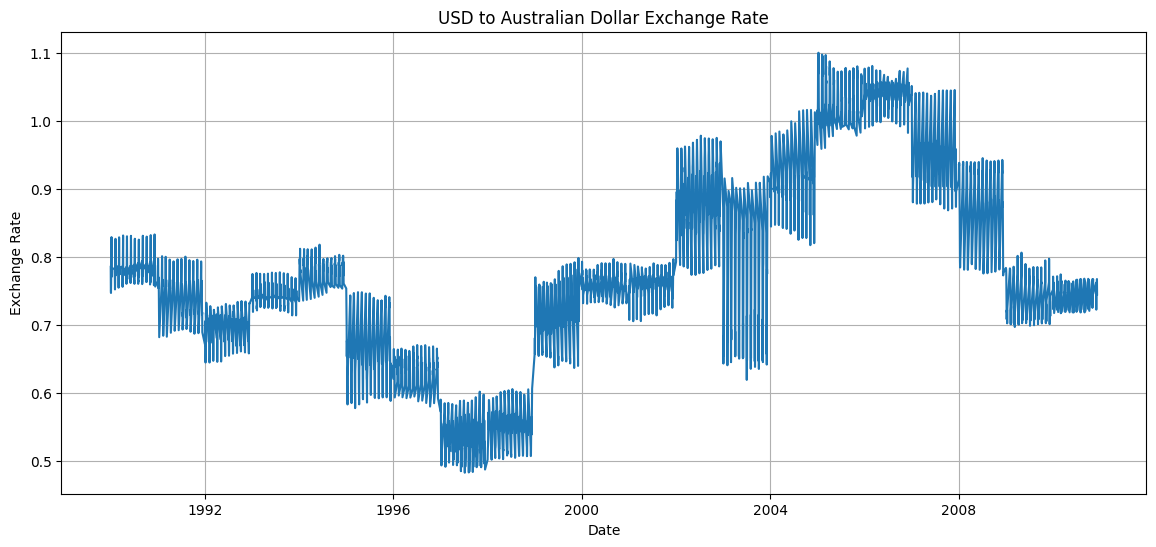

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(ts)

plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid(True)
plt.show()

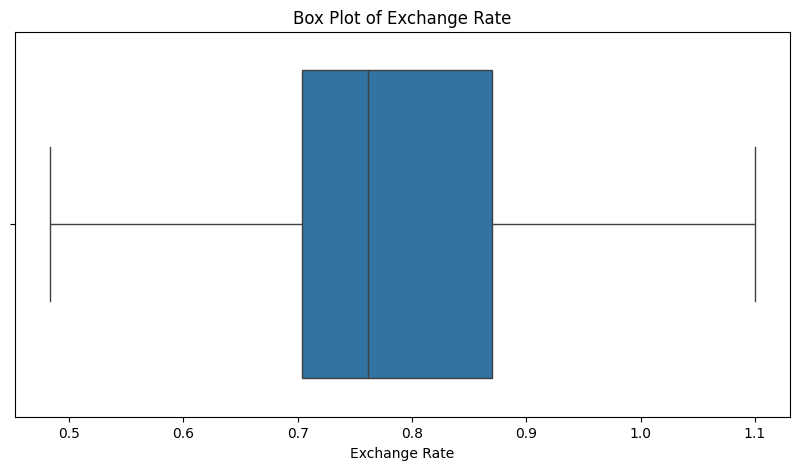

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=ts)

plt.title("Box Plot of Exchange Rate")
plt.xlabel("Exchange Rate")

plt.show()

In [ ]:
# Calculate Q1 and Q3
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Identify possible outliers
outliers = ts[
    (ts < lower_limit) |
    (ts > upper_limit)
]

print("Number of potential outliers:", len(outliers))
print(outliers.head())

Number of potential outliers: 0
Series([], Name: Ex_rate, dtype: float64)


In [ ]:
# Use 80% of data for training and 20% for testing

train_size = int(len(ts) * 0.80)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 2398
Testing observations: 600


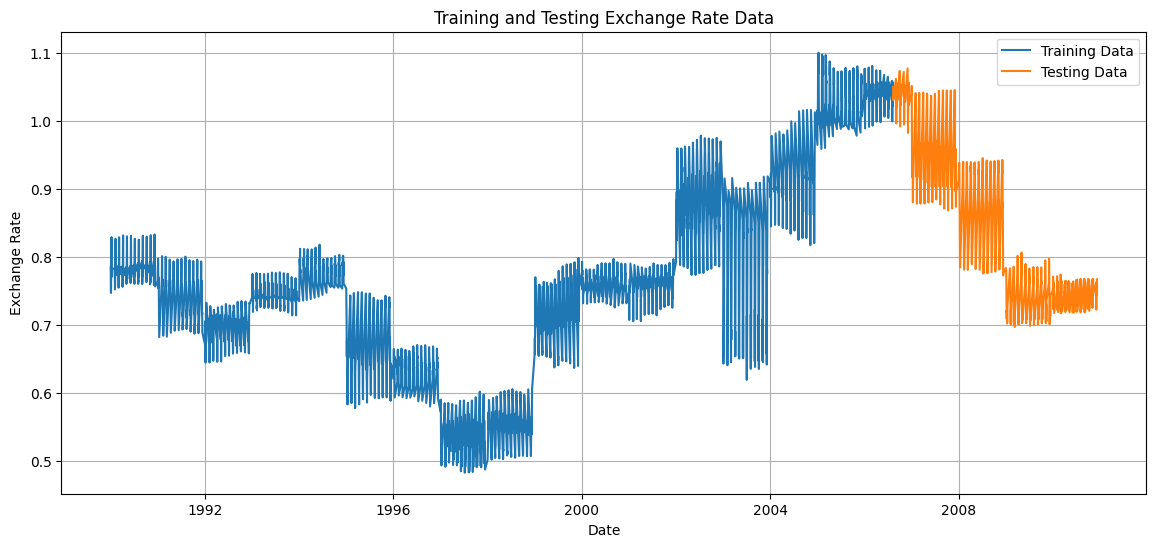

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Testing Data")

plt.title("Training and Testing Exchange Rate Data")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

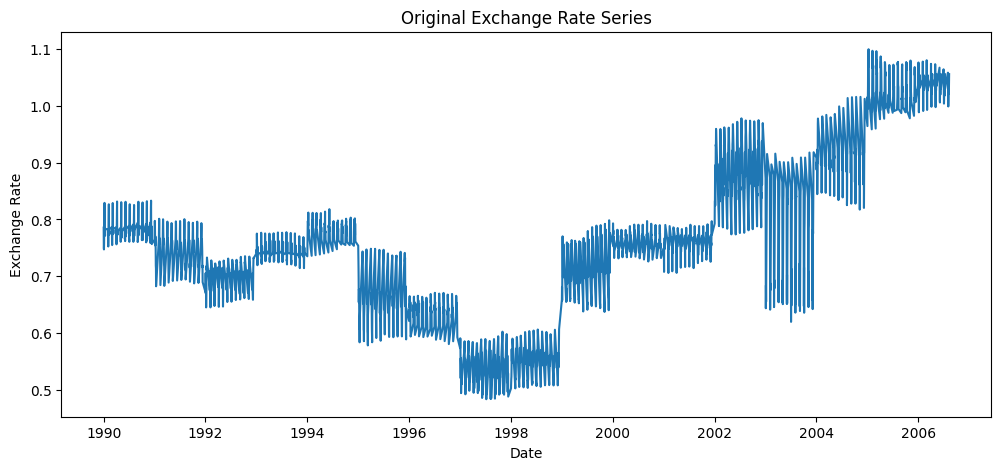

In [ ]:
# Plot original series

plt.figure(figsize=(12, 5))

plt.plot(train)

plt.title("Original Exchange Rate Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

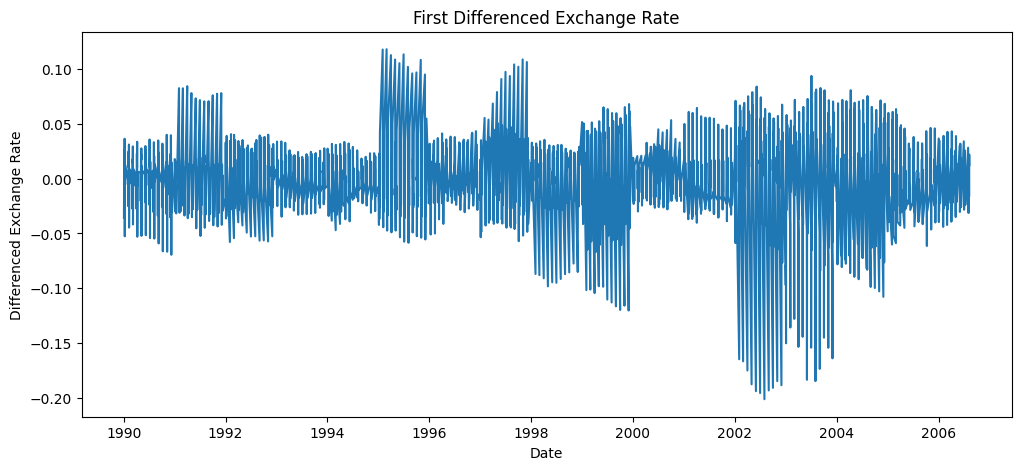

In [ ]:
# First-order differencing

train_diff = train.diff().dropna()

plt.figure(figsize=(12, 5))

plt.plot(train_diff)

plt.title("First Differenced Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")

plt.show()

<Figure size 1200x500 with 0 Axes>

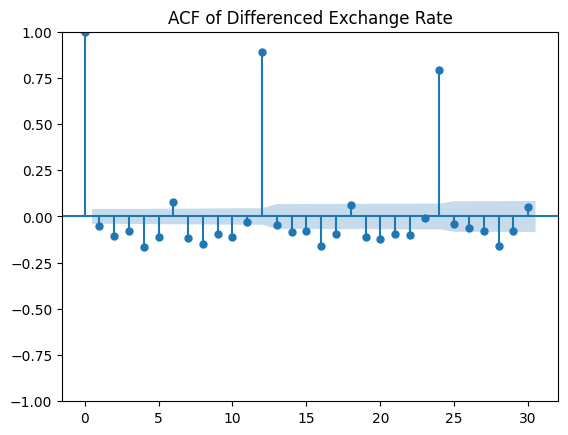

In [ ]:
plt.figure(figsize=(12, 5))

plot_acf(
    train_diff,
    lags=30
)

plt.title("ACF of Differenced Exchange Rate")

plt.show()

<Figure size 1200x500 with 0 Axes>

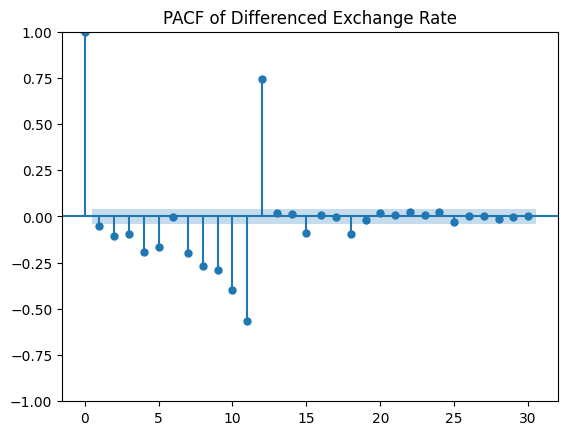

In [ ]:
plt.figure(figsize=(12, 5))

plot_pacf(
    train_diff,
    lags=30,
    method='ywm'
)

plt.title("PACF of Differenced Exchange Rate")

plt.show()

In [ ]:
# Build ARIMA(1,1,1) model

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

# Fit model
arima_result = arima_model.fit()

# Display model summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 2398
Model:                 ARIMA(1, 1, 1)   Log Likelihood                4774.834
Date:                Sun, 06 Sep 2026   AIC                          -9543.667
Time:                        09:17:47   BIC                          -9526.321
Sample:                             0   HQIC                         -9537.356
                               - 2398                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6482      0.018     36.456      0.000       0.613       0.683
ma.L1         -0.9397      0.008   -115.714      0.000      -0.956      -0.924
sigma2         0.0011   1.88e-05     57.849      0.0

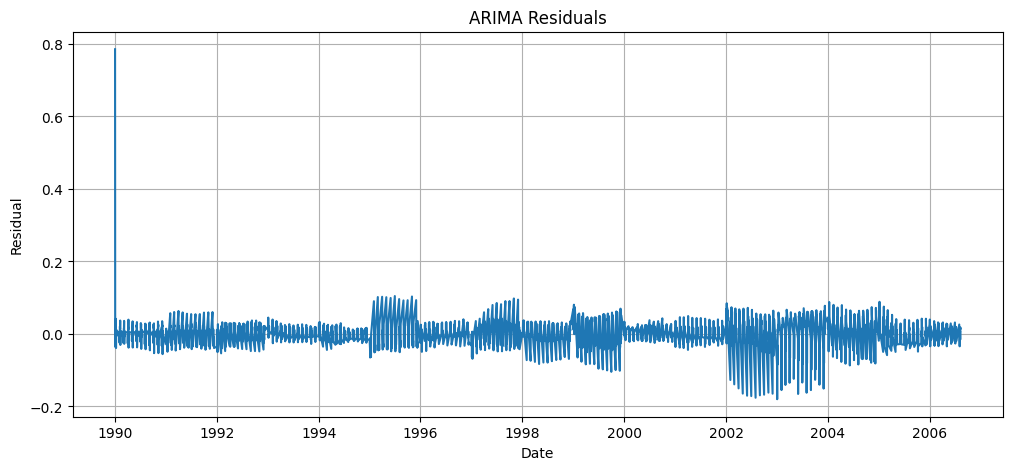

In [ ]:
# Get residuals

residuals = arima_result.resid

# Plot residuals

plt.figure(figsize=(12, 5))

plt.plot(residuals)

plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid(True)

plt.show()

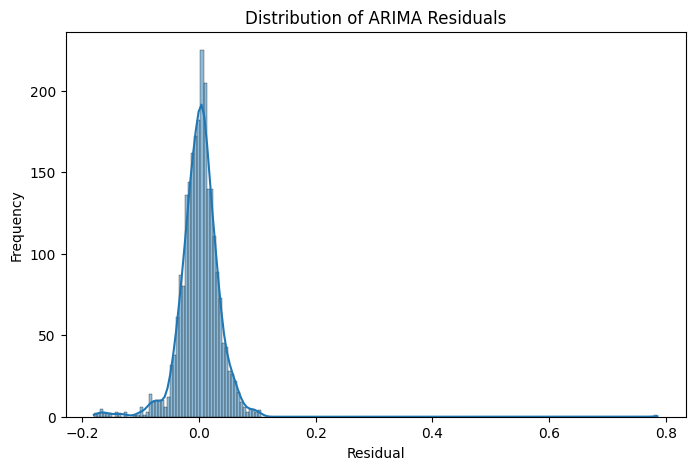

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

<Figure size 1200x500 with 0 Axes>

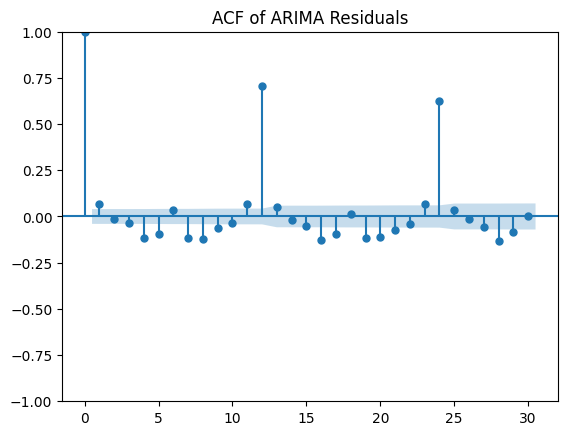

In [ ]:
plt.figure(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=30
)

plt.title("ACF of ARIMA Residuals")

plt.show()

In [ ]:
# Perform Ljung-Box test

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10],
    return_df=True
)

print(ljung_box)

      lb_stat     lb_pvalue
10  152.61603  1.078898e-27


In [ ]:
# Forecast the testing period
arima_forecast_raw = arima_result.forecast(steps=len(test))

# Explicitly assign the test index to the forecast
arima_forecast = arima_forecast_raw.copy()
arima_forecast.index = test.index

print(arima_forecast.head())

date
2006-08-11    1.049736
2006-08-12    1.045838
2006-09-01    1.043311
2006-09-02    1.041673
2006-09-03    1.040611
Name: predicted_mean, dtype: float64


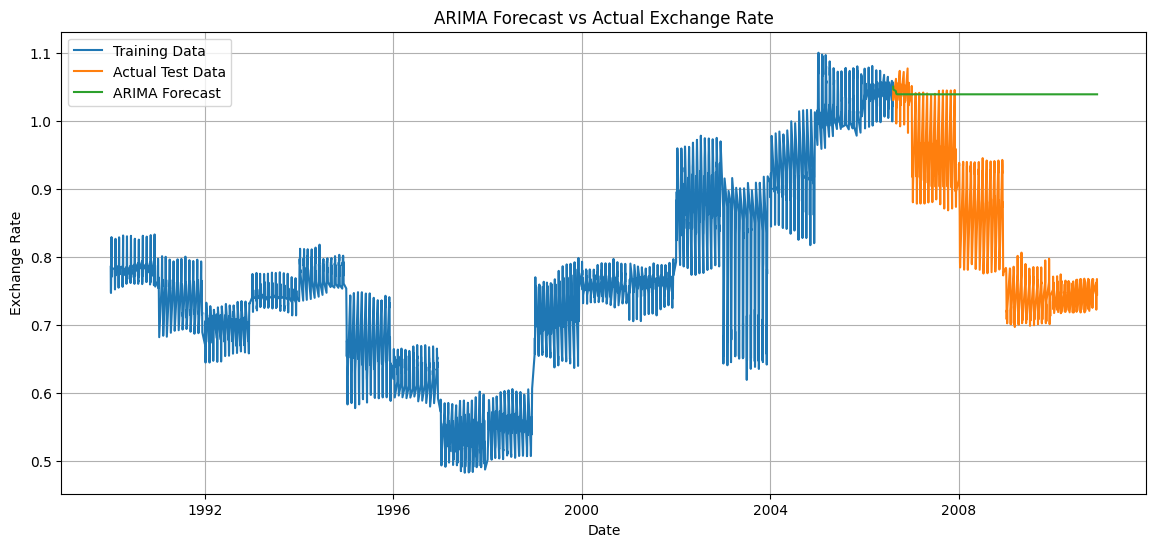

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Build Exponential Smoothing model

exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

# Fit model
exp_result = exp_model.fit()

print(exp_result.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 2398
Model:             ExponentialSmoothing   SSE                              2.985
Optimized:                         True   AIC                         -16031.902
Trend:                         Additive   BIC                         -16008.772
Seasonal:                          None   AICC                        -16031.867
Seasonal Periods:                  None   Date:                 Sun, 06 Sep 2026
Box-Cox:                          False   Time:                         09:18:18
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9363067                alpha                 True
smoothing_trend             0.0000

In [ ]:
# Forecast the testing period
exp_forecast_raw = exp_result.forecast(steps=len(test))

# Explicitly assign the test index to the forecast
exp_forecast = exp_forecast_raw.copy()
exp_forecast.index = test.index

print(exp_forecast.head())

date
2006-08-11    1.054998
2006-08-12    1.055111
2006-09-01    1.055225
2006-09-02    1.055338
2006-09-03    1.055451
dtype: float64


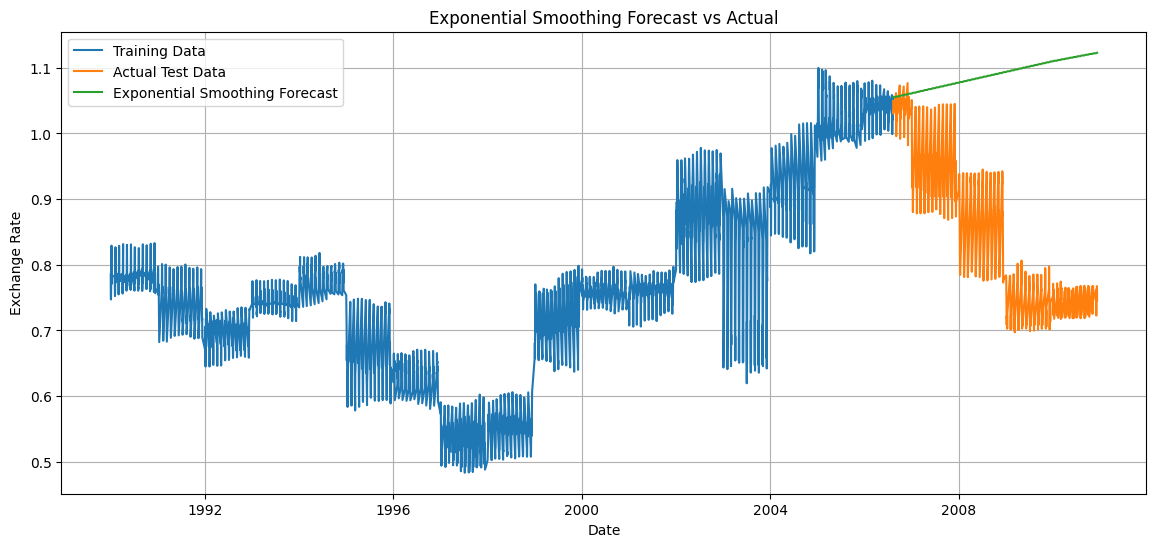

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(
    exp_forecast,
    label="Exponential Smoothing Forecast"
)

plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def evaluate_model(actual, predicted):

    # Mean Absolute Error
    mae = mean_absolute_error(
        actual,
        predicted
    )

    # Root Mean Squared Error
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # Mean Absolute Percentage Error
    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return mae, rmse, mape

In [ ]:
# Create a temporary DataFrame to align `test` and `arima_forecast` and drop NaNs
comparison_arima = pd.DataFrame({'actual': test, 'predicted': arima_forecast}).dropna()

arima_mae, arima_rmse, arima_mape = evaluate_model(
    comparison_arima['actual'],
    comparison_arima['predicted']
)

print("ARIMA Performance")
print("------------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape, "%")

ARIMA Performance
------------------
MAE : 0.19143475275954974
RMSE: 0.21936383899846434
MAPE: 24.537307237485333 %


In [ ]:
# Create a temporary DataFrame to align `test` and `exp_forecast` and drop NaNs
comparison_exp = pd.DataFrame({'actual': test, 'predicted': exp_forecast}).dropna()

exp_mae, exp_rmse, exp_mape = evaluate_model(
    comparison_exp['actual'],
    comparison_exp['predicted']
)

print("Exponential Smoothing Performance")
print("-----------------------------------")
print("MAE :", exp_mae)
print("RMSE:", exp_rmse)
print("MAPE:", exp_mape, "%")

Exponential Smoothing Performance
-----------------------------------
MAE : 0.24066140809821548
RMSE: 0.2718037209109105
MAPE: 30.715666779600298 %


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ARIMA",
        "Exponential Smoothing"
    ],

    "MAE": [
        arima_mae,
        exp_mae
    ],

    "RMSE": [
        arima_rmse,
        exp_rmse
    ],

    "MAPE": [
        arima_mape,
        exp_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.191435,0.219364,24.537307
1,Exponential Smoothing,0.240661,0.271804,30.715667


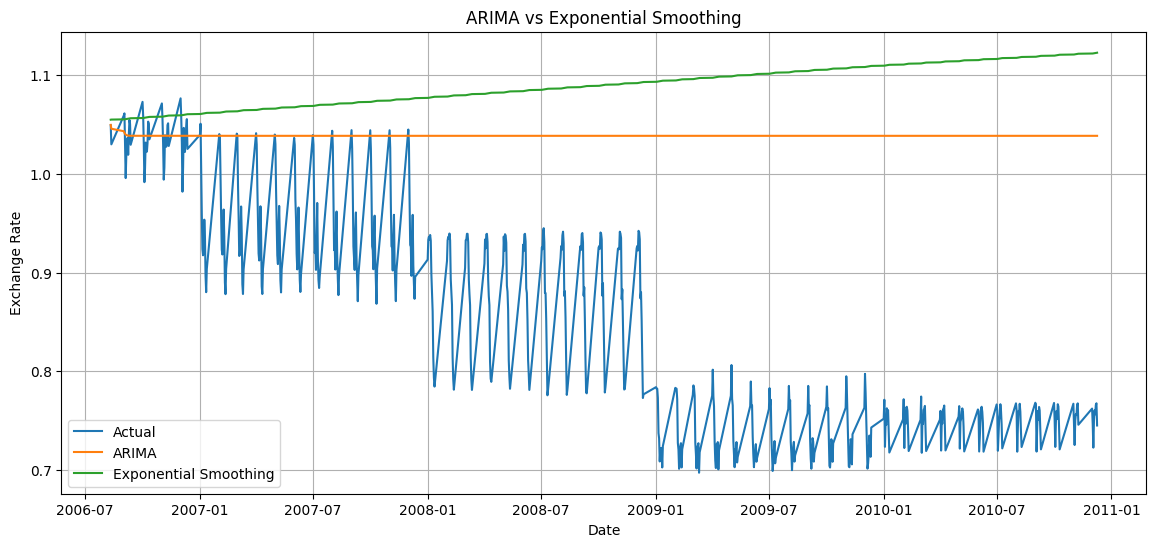

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    arima_forecast,
    label="ARIMA"
)

plt.plot(
    exp_forecast,
    label="Exponential Smoothing"
)

plt.title("ARIMA vs Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Find model with lowest RMSE

best_model = comparison.loc[
    comparison['RMSE'].idxmin(),
    'Model'
]

print("Best Model based on RMSE:", best_model)

Best Model based on RMSE: ARIMA


In [ ]:
print("Best model based on MAE:",
      comparison.loc[comparison['MAE'].idxmin(), 'Model'])

print("Best model based on RMSE:",
      comparison.loc[comparison['RMSE'].idxmin(), 'Model'])

print("Best model based on MAPE:",
      comparison.loc[comparison['MAPE'].idxmin(), 'Model'])

Best model based on MAE: ARIMA
Best model based on RMSE: ARIMA
Best model based on MAPE: ARIMA
